In [1]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [2]:
# ----------------------------
# 1) LTM store (START EMPTY)
# ----------------------------
store = InMemoryStore()

In [3]:
# ----------------------------
# 2) System prompt
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [4]:
# ----------------------------
# 3) Memory extraction LLM
# ----------------------------
memory_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [5]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory")
    is_new: bool = Field(description="True if new, false if duplicate")

In [6]:
class MemoryDecision(BaseModel):
    should_write: bool
    memories: List[MemoryItem] = Field(default_factory=list)

In [7]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [8]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return should_write=false and an empty list.
"""

In [9]:
# ----------------------------
# 4) Node 1: remember
# ----------------------------
def remember_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    # existing memory
    items = store.search(ns)
    existing = "\n".join(it.value["data"] for it in items) if items else "(empty)"

    # last user message
    last_msg = state["messages"][-1].content

    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=existing)),
            {"role": "user", "content": last_msg},
        ]
    )

    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(ns, str(uuid.uuid4()), {"data": mem.text})

    return {}  # no message change

In [10]:
# ----------------------------
# 5) Node 2: chat
# ----------------------------
chat_llm = ChatOpenAI(model="gpt-4o-mini")

In [11]:
def chat_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    items = store.search(ns)
    user_details = "\n".join(it.value["data"] for it in items) if items else ""

    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content=user_details or "(empty)"
        )
    )

    response = chat_llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

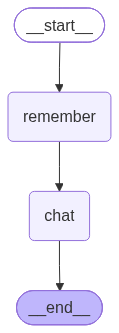

In [12]:
# ----------------------------
# 6) Graph
# ----------------------------
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_node)
builder.add_node("chat", chat_node)

builder.add_edge(START, "remember")
builder.add_edge("remember", "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [20]:
# ----------------------------
# 7) Demo
# ----------------------------
config = {"configurable": {"user_id": "session-1"}}

In [21]:
result = graph.invoke({"messages": [{"role": "user", "content": "Hi, my name is raju"}]}, config)
result['messages'][-1].content

"Hi Raju! It's great to meet you. How can I assist you today?"

In [23]:
for it in store.search(("user", "session-1", "details")):
    print(it.value["data"])

User's name is Raju.


In [24]:
result = graph.invoke({"messages": [{"role": "user", "content": "i'm currently working as an agentic ai engineer"}]}, config)
print(result['messages'][-1].content)

That's great to hear, Raju! As an agentic AI engineer, you must be involved in some fascinating projects. If there's anything specific you'd like to discuss or if you have questions about your work, feel free to ask! 

Here are a few questions to consider:
1. Are there any particular AI frameworks or tools you're currently using in your projects?
2. Have you encountered any challenges in your work lately that you’d like to brainstorm solutions for?
3. Are there specific areas within agentic AI that you're most passionate about or interested in exploring further?


In [25]:
for it in store.search(("user", "session-1", "details")):
    print(it.value["data"])

User's name is Raju.
User is currently working as an agentic AI engineer.


In [26]:
result = graph.invoke({"messages": [{"role": "user", "content": "Explain GenAI simply"}]}, config)
print(result['messages'][-1].content)

Sure, Raju! GenAI, or Generative AI, refers to a type of artificial intelligence that can create new content based on the data it has been trained on. This can include text, images, music, and more. Unlike traditional AI, which might analyze or classify existing data, generative AI uses patterns learned from data to generate original outputs.

For example, if you trained a generative AI on a collection of paintings, it could create new artworks that resemble those styles. In a text context, it might write essays, stories, or even poetry that mimic a certain writing style.

It's a powerful tool for creativity and innovation, allowing machines to contribute to artistic and intellectual endeavors in ways we haven't seen before!

Would you like to dive deeper into specific applications of GenAI or its underlying technology? Here are a few questions you might consider:

1. What specific applications of GenAI are you interested in exploring further?
2. Are there any challenges you've encount

In [27]:
for it in store.search(("user", "session-1", "details")):
    print(it.value["data"])

User's name is Raju.
User is currently working as an agentic AI engineer.
